# Three-body problem in Python 
This notebook solves the gravitational three-body problem. 
The solution is solved numerically using SciPy's [solve_ivp](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html) module. 

A list of periodic solutions to the three-body problem can be found [here](http://three-body.ipb.ac.rs/sol.php?id=2). 

In [10]:
# import needed libraries 
import numpy as np
%matplotlib inline 
import matplotlib.pyplot as plt

from numpy.linalg import norm 

from scipy.integrate import solve_ivp

from matplotlib import animation
from IPython.display import display, Image
from IPython.display import HTML

In [16]:
def rhs_threebody(t:"float",Y:"array", m1:"float", m2:"float", m3:"float"):
    '''
    Right hand side function for three-body ODE. 
    Computes the gravitational forces between the three particles, returns
    dY/dt, where Y = [postion of particles, velocity of particles], 18 elements in total, 
    x, y, z positions for and vx, vy, vz velocities for three particles. 
    
    parameters: 
        t, float, not used, only needed so that the function matches the call 
            structure needed by scipy's solve_ivp 
        Y, array, the position and velocity of the three particles, 
            the order is x_1, y_1, z_1, x_2, y_2, z_2, x_3, y_3, z_3, 
            vx_1, vy_1, vz_1, vx_2, vy_2, vz_2, vx_3, vy_3, vz_3, 
        m1, float, mass of particle 1 
        m2, float, mass of particle 2
        m3, float, mass of particle 3 

    returns: 
        dY/dt, array, the time derivatives of Y
        
    '''
    # positions of particles 1, 2, 3 
    r1=Y[:3]
    r2=Y[3:6]
    r3=Y[6:9]

    # velocities of particles 1, 2, 3 
    v1=Y[9:12]
    v2=Y[12:15]
    v3=Y[15:18] 

    # vectors between particles 1, 2, 3
    r12= r1 - r2
    r13 = r1 - r3
    r23 = r2 - r3 
    
    # forces 
    F12 = - m1*m2/norm(r12)**3*r12
    F13 = - m1*m3/norm(r13)**3*r13
    F23 = - m2*m3/norm(r23)**3*r23

    # force on each particle 
    F1 = F12 + F13
    F2 = - F12 + F23
    F3 = - F13 - F23

    # velocities 
    dr1 = v1
    dr2 = v2
    dr3 = v3

    # accelerations 
    dv1 = F1/m1
    dv2 = F2/m2
    dv3 = F3/m3
    
    return np.r_[dr1, dr2, dr3, dv1, dv2, dv3]

## Initial conditions
The code below sets the initial conditions, which are collected into an array called
Y0. The mass parameters are collected into a tuple called params. 

You can obtain example initial conditions [here](http://three-body.ipb.ac.rs/sol.php?id=2). 


In [17]:
# p1 and p2 from
p1=.08330
p2=0.127889

# positions 
r1=np.array([-1,0,0]) 
r2=np.array([1,0,0]) 
r3=np.array([0,0,0]) 

# velocities 
v1=np.array([p1, p2, 0]) 
v2=np.array([p1, p2, 0]) 
v3=np.array([-2*p1, -2*p2, 0]) 

# Y0, the initial position and velocity vector 
Y0=np.r_[r1, r2, r3, v1, v2, v3]

# mass 
m1=1
m2=1
m3=1

params=(m1, m2, m3) 

## Obtaining a solution
The code below sets the max time, tmax. The number of times steps, nt. A time array, t. Then numerically obtains a solution by calling solve_ivp. 

Note: 
* To get a stable solution you need to set the tolerance parameters, atol and rtol, to be be very small. I set both to 1e-10.
* By default solve_ivp with use the RK45 integrator. You may try other intergrators, see the solve_ivp documentation. 

In [18]:
# max time 
tmax=10.5
# time steps 
nt=2000
# time array 
t=np.linspace(0,tmax, nt)

# obtain solution
sol=solve_ivp(rhs_threebody, (0, tmax), Y0, t_eval=t, 
              dense_output=True, args=params, atol=1e-10, rtol=1e-10)

In [19]:
# The solution is obtained by using the key, "y". 
# The solution contains both the postions and velocities, but I will only plot 
# position, so I will only extract out those values. 
y=sol["y"]
r1=y[:3,:]
r2=y[3:6, :]
r3=y[6:9, :]

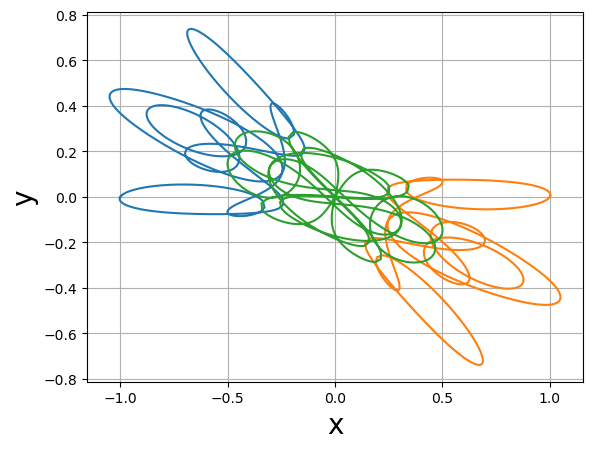

In [21]:
# plot the solution 
ax=plt.subplot()
ax.set_xlabel("x", size=20) 
ax.set_ylabel("y", size=20) 
ax.plot(r1[0,:], r1[1,:]) 
ax.plot(r2[0,:], r2[1,:]) 
ax.plot(r3[0,:], r3[1,:]) 
ax.grid()

In [23]:
# animation routine 
# First set up the figure, the axis, and the plot element we want to animate
fig=plt.figure()
ax=fig.add_subplot()
ax.set_xlim(-2, 2) 
ax.set_ylim(-2,2) 

p1, =ax.plot([], [], "o", markersize=5, color="blue")
p2, =ax.plot([], [], "o", markersize=5, color="purple")
p3, =ax.plot([], [], "o", markersize=5, color="green")

l1, =ax.plot([], [], lw=.5, color="blue") 
l2, =ax.plot([], [], lw=.5, color="purple")
l3, =ax.plot([], [], lw=.5, color="green") 
# line, = ax.plot([], [], lw=1)

# # Initialization function: plot the background of each frame
def init():
    p1.set_data([], [])
    p2.set_data([], [])
    p3.set_data([], [])
    l1.set_data([], [])
    l2.set_data([], [])
    l3.set_data([], [])
    return p1,p2, p3,l1, l2, l3, 

# Animation function which updates figure data.  This is called sequentially.
def animate(i):
    p1.set_data([r1[0,i]], [r1[1,i]])
    p2.set_data([r2[0,i]], [r2[1,i]])
    p3.set_data([r3[0,i]], [r3[1,i]])
    
    l1.set_data([r1[0,:i+1]], [r1[1,:i+1]])
    l2.set_data([r2[0,:i+1]], [r2[1,:i+1]])
    l3.set_data([r3[0,:i+1]], [r3[1,:i+1]])
    
    return p1,p2, p3, l1,l2, l3, 

# Call the animator.  blit=True means only re-draw the parts that have changed.
anim = animation.FuncAnimation(fig, animate, init_func=init,
                               frames=nt, interval=10, blit=True)

plt.close(anim._fig)

# Call function to display the animation
HTML(anim.to_html5_video())